Link Google Colab: https://colab.research.google.com/drive/1ng1sGZHCbPBCwahF5hnKbIH6DQ9QgFtf?usp=sharing

# Model BERT: IndoBERT untuk Klasifikasi Spoiler Review Goodreads

**Input:** `review_preprocessed.csv`  
**Kolom yang dipakai:** `review_text_clean`, `spoiler_label`  
**Model:** `indobenchmark/indobert-base-p2`  
**Environment:** Google Colab + GPU T4

---

## Kenapa BERT? Apa bedanya dengan BiLSTM?

Di notebook sebelumnya, BiLSTM membaca teks kata per kata secara berurutan, dari kiri ke kanan dan kanan ke kiri. Pendekatan ini sudah jauh lebih baik dari SVM atau Random Forest yang sama sekali tidak mempedulikan urutan kata. Tapi BiLSTM masih punya satu kelemahan besar: ia dilatih dari nol menggunakan data kita yang hanya sekitar 8.695 baris.

**BERT (Bidirectional Encoder Representations from Transformers)** bekerja dengan cara yang fundamentally berbeda. BERT sudah dilatih terlebih dahulu pada ratusan juta kata sebelum menyentuh data kita sama sekali. Proses awal ini disebut **pre-training**, dan ketika selesai, BERT sudah memiliki pemahaman mendalam tentang bagaimana kata-kata saling berhubungan dalam sebuah bahasa.

Kita hanya perlu mengajarkan BERT hal yang satu lagi: "hei, dari semua yang sudah kamu pahami tentang bahasa, tolong gunakan itu untuk membedakan mana review yang spoiler dan mana yang bukan." Proses ini disebut **fine-tuning**, dan biasanya hanya butuh beberapa epoch saja karena fondasinya sudah sangat kuat.

Analoginya seperti ini: BiLSTM seperti seseorang yang baru belajar bahasa Indonesia dari nol hanya dari 8.695 kalimat. BERT seperti penutur asli yang sudah membaca jutaan artikel dan buku, lalu diminta belajar satu tugas spesifik baru.

---

## Kenapa IndoBERT, bukan XLM-RoBERTa atau yang lain?

Ada beberapa model BERT yang tersedia, dan pilihannya penting:

- **XLM-RoBERTa**: model multilingual yang dilatih pada 100 bahasa sekaligus. Bagus, tapi kapasitasnya dibagi ke 99 bahasa lain sehingga pemahamannya untuk bahasa Indonesia tidak sedalam model monolingual.
- **mBERT (multilingual BERT)**: versi awal dari model multilingual Google, kualitasnya umumnya di bawah XLM-RoBERTa.
- **RoBERTa**: dilatih pada bahasa Inggris saja, tidak relevan untuk data kita.
- **IndoBERT**: dilatih **khusus** pada korpus bahasa Indonesia dari Wikipedia Indonesia, berita, dan web crawl. Karena fokusnya satu bahasa saja, representasi yang dipelajari jauh lebih kaya dan lebih dalam untuk nuansa bahasa Indonesia, termasuk bahasa informal yang umum di review Goodreads.

Versi yang digunakan adalah `indobenchmark/indobert-base-p2`. Ada dua versi IndoBERT (p1 dan p2), di mana p2 dilatih dengan data yang lebih bersih dan secara konsisten menghasilkan performa lebih baik pada tugas klasifikasi teks.

---

## Bagaimana BERT memproses teks?

BERT tidak menggunakan TF-IDF dan tidak memproses kata per kata seperti LSTM. BERT menggunakan mekanisme yang disebut **self-attention**: setiap kata dalam kalimat memperhatikan semua kata lain secara bersamaan, lalu memutuskan kata mana yang paling relevan untuk memahami maknanya.

Contoh: dalam kalimat "ternyata dia yang membunuh tokoh utama di akhir cerita", kata "membunuh" akan memberikan perhatian besar ke kata "ternyata" dan "tokoh utama" karena keduanya paling relevan untuk memahami konteks kalimat itu sebagai spoiler.

Setiap input ke BERT dimulai dengan token khusus `[CLS]` (classification) dan diakhiri dengan `[SEP]` (separator). Representasi dari token `[CLS]` di layer terakhir digunakan sebagai representasi keseluruhan kalimat, dan inilah yang kita masukkan ke layer klasifikasi.

---

## Alur Kerja Notebook Ini

```
review_preprocessed.csv
        |
        v
[1] setup: verifikasi GPU, install library
        |
        v
[2] load & eksplorasi data
        |
        v
[3] tokenisasi dengan IndoBERT tokenizer
        |
        v
[4] stratified train-val-test split
        |
        v
[5] buat Dataset object untuk HuggingFace Trainer
        |
        v
[6] load model IndoBERT + definisi WeightedTrainer
        |
        v
[7] training dengan early stopping
        |
        v
[8] evaluasi lengkap + threshold tuning di val set
        |
        v
[9] plot training history
        |
        v
[10] kesimpulan
```

## 0. Verifikasi GPU

IndoBERT adalah model yang cukup besar. Fine-tuning tanpa GPU bisa memakan waktu berjam-jam untuk satu epoch saja. Pastikan runtime sudah diatur ke GPU T4 sebelum menjalankan apapun.

Caranya di Colab: **Runtime → Change runtime type → T4 GPU**

In [1]:
# cek apakah GPU tersedia dan modelnya apa
import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode == 0:
  print("GPU tersedia!")
  # tampilkan baris pertama saja yang berisi nama GPU
  for line in result.stdout.split("\n"):
    if "Tesla" in line or "T4" in line or "A100" in line or "V100" in line:
      print(line)
      break
else:
  print("GPU tidak terdeteksi!")

GPU tersedia!
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |


## 1. Instalasi dan Import Library

In [2]:
# transformers: library utama dari HuggingFace yang berisi model BERT dan Trainer
# datasets    : format data yang digunakan oleh HuggingFace Trainer
# accelerate  : diperlukan oleh Trainer untuk manajemen GPU
!pip install -q transformers datasets accelerate

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import torch

from transformers import (
  AutoTokenizer,
  AutoModelForSequenceClassification,
  TrainingArguments,
  Trainer,
  EarlyStoppingCallback
)
from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
  classification_report,
  confusion_matrix,
  roc_auc_score,
  roc_curve,
  f1_score,
  precision_score,
  recall_score,
  ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# konfigurasi utama
MODEL_NAME = "indobenchmark/indobert-base-p2"  # model yang akan di-fine-tune
RANDOM_SEED = 42
MAX_LEN = 256         # panjang token maksimum per input
BATCH_SIZE = 16       # jumlah sampel per batch saat training
MAX_EPOCHS = 10       # EarlyStoppingCallback akan berhenti lebih awal jika tidak ada perbaikan
LEARNING_RATE = 5e-6  # learning rate kecil karena kita fine-tuning, bukan training dari nol

# set seed untuk reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch versi: {torch.__version__}")
print(f"GPU tersedia: {torch.cuda.is_available()}")
if torch.cuda.is_available():
  print(f"Nama GPU: {torch.cuda.get_device_name(0)}")
  print(f"Memory GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch versi: 2.11.0+cu128
GPU tersedia: True
Nama GPU: Tesla T4
Memory GPU: 15.6 GB


## 2. Mount Google Drive dan Load Data

In [4]:
from google.colab import drive
drive.mount("/content/drive")

# sesuaikan path ini dengan lokasi file di Google Drive kamu
DRIVE_BASE = "/content/drive/MyDrive/NLP_Kelompok3"
INPUT_CSV = os.path.join(DRIVE_BASE, "review_preprocessed.csv")
OUTPUT_DIR = os.path.join(DRIVE_BASE, "indobert_output")  # folder untuk simpan checkpoint

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"path dataset: {INPUT_CSV}")
print(f"output dir: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
path dataset: /content/drive/MyDrive/NLP_Kelompok3/review_preprocessed.csv
output dir: /content/drive/MyDrive/NLP_Kelompok3/indobert_output


In [5]:
# load dataset
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

print(f"total baris: {len(df)}")
print(f"kolom: {list(df.columns)}")

# cek missing value pada kolom yang akan dipakai
print("\nmissing values")
print(df[["review_text_clean", "spoiler_label"]].isnull().sum())

# hapus baris yang kolom utamanya kosong
df = df.dropna(subset=["review_text_clean", "spoiler_label"]).reset_index(drop=True)
print(f"\nsetelah hapus missing: {len(df)} baris")

total baris: 11267
kolom: ['review_text_clean', 'review_text_stem', 'spoiler_label']

missing values
review_text_clean    0
spoiler_label        0
dtype: int64

setelah hapus missing: 11267 baris


In [6]:
# cek distribusi label dan hitung imbalance ratio
label_counts = df["spoiler_label"].value_counts()
n_nonspoiler = label_counts[0]
n_spoiler = label_counts[1]
imbalance_ratio = n_nonspoiler / n_spoiler

print("distribusi label")
print(pd.DataFrame({
  "jumlah" : label_counts,
  "persen" : (label_counts / len(df) * 100).round(2)
}).rename(index={0: "non-spoiler (0)", 1: "spoiler (1)"}))

print(f"\nimbalance ratio: {imbalance_ratio:.2f}")

# siapkan data X dan y
texts = df["review_text_clean"].astype(str).tolist()
labels = df["spoiler_label"].astype(int).tolist()

distribusi label
                 jumlah  persen
spoiler_label                  
non-spoiler (0)   10281   91.25
spoiler (1)         986    8.75

imbalance ratio: 10.43


## 3. Tokenisasi dengan IndoBERT Tokenizer

### Apa itu tokenizer?

BERT tidak menerima teks mentah. Teks harus diubah dulu menjadi urutan angka yang merepresentasikan token, yaitu satuan teks terkecil yang dikenali model.

Yang menarik dari tokenizer BERT adalah ia tidak selalu memotong berdasarkan spasi (per kata). BERT menggunakan **WordPiece tokenization**: kata yang umum dipertahankan utuh, tapi kata yang jarang atau kata yang tidak dikenal dipecah menjadi sub-kata. Misalnya kata "mempermasalahkan" mungkin dipecah menjadi ["memper", "##masalah", "##kan"]. Tanda `##` artinya sub-kata itu adalah lanjutan dari kata sebelumnya.

Ini sangat berguna untuk bahasa Indonesia yang kaya afiksasi, karena model tetap bisa mengenali kata-kata baru yang belum pernah dilihat sebelumnya selama morfem pembentuknya dikenal.

### Kenapa MAX_LEN = 256?

BERT memiliki batas maksimum 512 token per input. Tapi semakin panjang input, semakin besar memori GPU yang dibutuhkan dan semakin lambat training. Persentil ke-90 panjang review dalam data ini adalah 1.773 kata, artinya banyak review yang jauh melebihi batas BERT bahkan pada 512 token.

Pilihan 256 token adalah kompromi yang umum dipakai: cukup menangkap bagian awal review yang biasanya paling informatif, sambil menjaga memori GPU tetap manageable dengan batch size 16. Kalau kamu punya GPU dengan VRAM lebih besar (misalnya A100), kamu bisa naikkan ke 512.

In [7]:
# load tokenizer IndoBERT dari HuggingFace
# pertama kali dijalankan akan download file ~500MB dari internet
print(f"loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"\nukuran vocabulary tokenizer: {tokenizer.vocab_size:,} token")
print(f"token khusus: {tokenizer.all_special_tokens}")

loading tokenizer: indobenchmark/indobert-base-p2



ukuran vocabulary tokenizer: 30,521 token
token khusus: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']


In [8]:
# contoh tokenisasi untuk memahami cara kerja tokenizer
contoh = "ternyata si pembunuhnya adalah ayah dari tokoh utama sendiri"
tokens = tokenizer.tokenize(contoh)
ids = tokenizer.encode(contoh)

print(f"teks asli: {contoh}")
print(f"tokens: {tokens}")
print(f"token IDs: {ids}")
print(f"\nperhatikan: [CLS] ditambahkan di awal (ID={tokenizer.cls_token_id})")
print(f"dan [SEP] ditambahkan di akhir (ID={tokenizer.sep_token_id})")

teks asli: ternyata si pembunuhnya adalah ayah dari tokoh utama sendiri
tokens: ['ternyata', 'si', 'pembunuh', '##nya', 'adalah', 'ayah', 'dari', 'tokoh', 'utama', 'sendiri']
token IDs: [2, 1369, 356, 11767, 57, 154, 2161, 98, 2546, 1256, 536, 3]

perhatikan: [CLS] ditambahkan di awal (ID=2)
dan [SEP] ditambahkan di akhir (ID=3)


In [9]:
# analisis distribusi panjang token pada data kita
# ini penting untuk memahami seberapa banyak teks yang terpotong oleh MAX_LEN=256
print("menghitung panjang token semua review (bisa beberapa menit)...")

token_lengths = []
for text in texts:
  tokens = tokenizer.encode(text, add_special_tokens=True)
  token_lengths.append(len(tokens))

print("\ndistribusi panjang token")
for p in [25, 50, 75, 90, 95, 99]:
  print(f"persentil {p:3d}: {np.percentile(token_lengths, p):.0f} token")
print(f"maksimum: {max(token_lengths)} token")

covered = sum(1 for l in token_lengths if l <= MAX_LEN)
print(f"\nreview yang masuk penuh (<= {MAX_LEN} token): {covered}/{len(texts)} ({covered/len(texts)*100:.1f}%)")
print(f"review yang terpotong: {len(texts)-covered}/{len(texts)} ({(len(texts)-covered)/len(texts)*100:.1f}%)")

menghitung panjang token semua review (bisa beberapa menit)...

distribusi panjang token
persentil  25: 41 token
persentil  50: 91 token
persentil  75: 192 token
persentil  90: 336 token
persentil  95: 436 token
persentil  99: 748 token
maksimum: 2582 token

review yang masuk penuh (<= 256 token): 9374/11267 (83.2%)
review yang terpotong: 1893/11267 (16.8%)


## 4. Pembagian Data: Train, Validation, Test

### Kenapa butuh tiga partisi?

Di notebook ML dan BiLSTM kita hanya pakai train dan test. Untuk BERT, kita butuh **validation set yang terpisah** karena:

1. **EarlyStopping** memantau metrik di validation set untuk memutuskan kapan berhenti. Kalau tidak ada validation set, kita tidak tahu apakah model mulai overfitting.
2. **Threshold tuning** harus dilakukan di validation set, bukan test set. Kalau threshold dicari di test set, kita sudah "melihat" data uji saat memilih parameter, sehingga hasil evaluasinya tidak valid.

Test set hanya disentuh satu kali di akhir, untuk evaluasi final.

In [10]:
# langkah 1: pisahkan test set dulu (80% sisa + 20% test)
X_temp, X_test, y_temp, y_test = train_test_split(
  texts, labels,
  test_size=0.2,
  stratify=labels, # pastikan proporsi label sama
  random_state=RANDOM_SEED
)

# langkah 2: dari 80% sisanya, ambil 15% untuk validation
# hasil akhir: ~68% train, ~12% val, ~20% test
X_train, X_val, y_train, y_val = train_test_split(
  X_temp, y_temp,
  test_size=0.15,
  stratify=y_temp,
  random_state=RANDOM_SEED
)

print(f"train set: {len(X_train)} sampel")
print(f"val set: {len(X_val)} sampel")
print(f"test set: {len(X_test)} sampel")

# verifikasi proporsi label di setiap partisi
print("\nproporsi spoiler per partisi")
for nama, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
  ratio = sum(y) / len(y)
  print(f"  {nama:5s} : {sum(y)} spoiler dari {len(y)} ({ratio*100:.2f}%)")

# hitung class weight berdasarkan distribusi di train set
n_train_spoiler = sum(y_train)
n_train_nonspoiler = len(y_train) - n_train_spoiler
weight_nonspoiler = len(y_train) / (2 * n_train_nonspoiler)
weight_spoiler = len(y_train) / (2 * n_train_spoiler)

print(f"\nclass weight yang akan dipakai:")
print(f"non-spoiler (0): {weight_nonspoiler:.4f}")
print(f"spoiler (1): {weight_spoiler:.4f}")
print(f"artinya: kesalahan pada spoiler dihukum {weight_spoiler/weight_nonspoiler:.1f}x lebih berat")

train set: 7661 sampel
val set: 1352 sampel
test set: 2254 sampel

proporsi spoiler per partisi
  train : 671 spoiler dari 7661 (8.76%)
  val   : 118 spoiler dari 1352 (8.73%)
  test  : 197 spoiler dari 2254 (8.74%)

class weight yang akan dipakai:
non-spoiler (0): 0.5480
spoiler (1): 5.7086
artinya: kesalahan pada spoiler dihukum 10.4x lebih berat


## 5. Membuat Dataset Object

HuggingFace `Trainer` membutuhkan data dalam format `torch.utils.data.Dataset`, bukan DataFrame biasa. Kita perlu membuat class khusus yang:

1. Menerima list teks dan label
2. Melakukan tokenisasi saat data diakses
3. Mengembalikan dictionary berisi `input_ids`, `attention_mask`, dan `labels`

**Apa itu `attention_mask`?** Karena semua input di-padding ke panjang yang sama (MAX_LEN), ada banyak token padding `[PAD]` di akhir teks yang pendek. `attention_mask` adalah array berisi 1 dan 0: nilai 1 untuk token nyata dan 0 untuk token padding. BERT menggunakan mask ini untuk mengabaikan token padding saat menghitung self-attention.

In [11]:
class SpoilerDataset(Dataset):
  """
  dataset class untuk HuggingFace Trainer.
  menerima list teks dan label, mengembalikan tensor yang siap diproses BERT.
  """

  def __init__(self, texts, labels, tokenizer, max_len):
    self.texts = texts
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    # wajib ada: memberitahu Trainer berapa banyak sampel yang ada
    return len(self.texts)

  def __getitem__(self, idx):
    # wajib ada: dipanggil setiap kali Trainer minta satu sampel
    text  = str(self.texts[idx])
    label = int(self.labels[idx])

    # tokenisasi teks
    # truncation=True  : potong jika lebih dari max_len
    # padding='max_length': pad sampai tepat max_len
    # return_tensors='pt' : kembalikan sebagai PyTorch tensor
    encoding = self.tokenizer(
      text,
      max_length=self.max_len,
      padding="max_length",
      truncation=True,
      return_tensors="pt"
    )

    return {
      # squeeze() untuk menghilangkan dimensi batch yang tidak diperlukan
      "input_ids"      : encoding["input_ids"].squeeze(),
      "attention_mask" : encoding["attention_mask"].squeeze(),
      "labels"         : torch.tensor(label, dtype=torch.long)
    }

# buat dataset object untuk masing-masing partisi
train_dataset = SpoilerDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = SpoilerDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = SpoilerDataset(X_test,  y_test,  tokenizer, MAX_LEN)

print(f"train dataset: {len(train_dataset)} sampel")
print(f"val dataset: {len(val_dataset)} sampel")
print(f"test dataset: {len(test_dataset)} sampel")

# cek satu sampel untuk memastikan format sudah benar
sampel = train_dataset[0]
print(f"\nbentuk input_ids: {sampel['input_ids'].shape}")
print(f"bentuk attention_mask: {sampel['attention_mask'].shape}")
print(f"label: {sampel['labels']}")

train dataset: 7661 sampel
val dataset: 1352 sampel
test dataset: 2254 sampel

bentuk input_ids: torch.Size([256])
bentuk attention_mask: torch.Size([256])
label: 0


## 6. Load Model dan Definisi WeightedTrainer

### Cara kerja fine-tuning

Ketika kita load `AutoModelForSequenceClassification`, yang terjadi adalah:

1. Seluruh bobot IndoBERT yang sudah di-pretrain dimuat dari HuggingFace, ini yang berisi "pemahaman bahasa" yang sudah dipelajari dari jutaan kata.
2. Di atas BERT, ditambahkan satu layer klasifikasi kecil (linear layer) yang outputnya adalah 2 nilai, yaitu skor untuk non-spoiler dan skor untuk spoiler.
3. Layer klasifikasi ini diinisialisasi secara acak karena memang belum pernah dilatih sebelumnya.

Selama fine-tuning, **seluruh bobot diupdate**, baik layer BERT maupun layer klasifikasi. Tapi karena learning rate yang sangat kecil (2e-5), perubahan pada bobot BERT sangat halus sehingga pengetahuan bahasa yang sudah dimiliki tidak rusak.

### Kenapa butuh WeightedTrainer?

Trainer default dari HuggingFace menggunakan `CrossEntropyLoss` biasa yang memperlakukan semua kelas dengan bobot yang sama. Untuk data imbalanced seperti kasus kita, ini bermasalah.

Kita membuat subclass `WeightedTrainer` yang meng-override metode `compute_loss` dengan loss function yang memberikan bobot lebih tinggi ke kelas spoiler. Setiap kali model salah mengklasifikasikan satu spoiler, penaltinya jauh lebih besar dari salah mengklasifikasikan satu non-spoiler.

In [12]:
# load model IndoBERT dengan classification head
# num_labels=2: dua kelas (non-spoiler dan spoiler)
# pertama kali dijalankan akan download bobot model ~500MB
print(f"loading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
  MODEL_NAME,
  num_labels=2,
  # ignore_mismatched_sizes karena kita menambahkan classification head baru
  ignore_mismatched_sizes=True
)

# hitung total parameter model
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\ntotal parameter: {total_params:,}")
print(f"yang di-train: {trainable:,}")

loading model: indobenchmark/indobert-base-p2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



total parameter: 124,442,882
yang di-train: 124,442,882


In [13]:
class WeightedTrainer(Trainer):
  """
  subclass dari HuggingFace Trainer yang mengganti loss function standar
  dengan weighted cross entropy loss untuk menangani imbalanced class.

  cara kerjanya: setiap sampel spoiler (kelas 1) mendapat bobot lebih besar
  dalam perhitungan loss, sehingga model lebih fokus belajar dari spoiler
  yang jumlahnya sedikit.
  """

  def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
    # ambil label dari batch
    labels = inputs.get("labels")

    # jalankan model untuk dapat prediksi
    outputs = model(**inputs)
    logits  = outputs.get("logits")

    # definisikan bobot per kelas
    # bobot dikirim ke device yang sama dengan logits (GPU atau CPU)
    class_weights = torch.tensor(
        [weight_nonspoiler, weight_spoiler],
        dtype=torch.float
    ).to(logits.device)

    # hitung weighted cross entropy loss
    loss_fn = CrossEntropyLoss(weight=class_weights)
    loss    = loss_fn(logits, labels)

    return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
  """
  fungsi untuk menghitung metrik evaluasi selama training.
  dipanggil di akhir setiap epoch oleh Trainer.
  """
  logits, labels = eval_pred
  # ambil kelas dengan skor tertinggi sebagai prediksi
  predictions = np.argmax(logits, axis=-1)
  # hitung probabilitas kelas spoiler menggunakan softmax
  probs_spoiler = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

  auc = roc_auc_score(labels, probs_spoiler)
  f1  = f1_score(labels, predictions, pos_label=1, zero_division=0)
  rec = recall_score(labels, predictions, pos_label=1, zero_division=0)

  return {
    "auc_roc"       : round(auc, 4),
    "f1_spoiler"    : round(f1, 4),
    "recall_spoiler": round(rec, 4)
  }

## 7. Training

### Apa itu TrainingArguments?

`TrainingArguments` adalah objek konfigurasi yang memberitahu Trainer bagaimana cara melatih model: berapa epoch, berapa batch size, seberapa sering evaluasi dilakukan, metrik mana yang dipantau untuk early stopping, dan ke mana model disimpan.

### Mengapa learning rate 2e-5?

Learning rate yang sangat kecil ini adalah standar untuk fine-tuning model BERT. Alasannya: bobot BERT sudah dalam kondisi yang sangat baik dari pre-training. Kalau learning rate terlalu besar, gradient dari layer klasifikasi yang masih acak akan merusak representasi yang sudah dipelajari selama pre-training. Nilai 2e-5 memungkinkan penyesuaian yang halus dan terkontrol.

### Warmup steps

Di awal training, learning rate tidak langsung penuh. Selama beberapa langkah pertama (warmup), learning rate dinaikkan secara bertahap dari nol ke nilai target. Ini membantu stabilisasi di awal training saat model masih sangat tidak stabil.

In [14]:
# hitung total training steps untuk konfigurasi warmup
steps_per_epoch = len(train_dataset) // BATCH_SIZE
warmup_steps = steps_per_epoch * 1  # warmup selama 1 epoch pertama
total_steps = steps_per_epoch * MAX_EPOCHS

print(f"sampel train: {len(train_dataset)}")
print(f"steps per epoch: {steps_per_epoch}")
print(f"warmup steps: {warmup_steps}")
print(f"total steps (maks): {total_steps}")

training_args = TrainingArguments(
  output_dir=OUTPUT_DIR,

  # konfigurasi training
  num_train_epochs=MAX_EPOCHS,
  per_device_train_batch_size=BATCH_SIZE,
  per_device_eval_batch_size=BATCH_SIZE,
  learning_rate=LEARNING_RATE,
  warmup_steps=warmup_steps,

  # weight decay: regularisasi tambahan untuk mencegah overfitting
  # bekerja dengan mengecilkan bobot model setiap step
  weight_decay=0.1,

  # konfigurasi evaluasi dan penyimpanan
  # eval_strategy='epoch' berarti evaluasi dilakukan di akhir setiap epoch
  eval_strategy="epoch",
  save_strategy="epoch",

  # pantau auc_roc untuk menentukan model terbaik dan early stopping
  metric_for_best_model="auc_roc",
  greater_is_better=True,
  load_best_model_at_end=True,   # setelah training selesai, muat bobot terbaik

  # simpan maksimal 2 checkpoint untuk hemat storage
  save_total_limit=2,

  logging_dir=os.path.join(OUTPUT_DIR, "logs"),
  logging_steps=steps_per_epoch,  # log setiap epoch

  # fp16=True menggunakan 16-bit floating point untuk mempercepat training di GPU
  fp16=torch.cuda.is_available(),

  seed=RANDOM_SEED,
  report_to="none" # matikan wandb/tensorboard logging
)

sampel train: 7661
steps per epoch: 478
warmup steps: 478
total steps (maks): 4780


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [15]:
# inisialisasi trainer
trainer = WeightedTrainer(
  model=model,
  args=training_args,
  train_dataset=train_dataset,
  eval_dataset=val_dataset,
  compute_metrics=compute_metrics,
  callbacks=[
    # hentikan training jika AUC validasi tidak meningkat selama 3 epoch berturut-turut
    # restore_best_model=True memastikan bobot terbaik yang digunakan di akhir
    EarlyStoppingCallback(early_stopping_patience=2)
  ]
)

# mulai training
# estimasi waktu: 5-15 menit per epoch di GPU T4 tergantung panjang data
print("memulai training IndoBERT...")
print(f"maksimum {MAX_EPOCHS} epoch, bisa berhenti lebih awal (early stopping patience=3)")
print()

train_result = trainer.train()

print(f"\ntraining selesai!")
print(f"total waktu training: {train_result.metrics['train_runtime']:.1f} detik")
print(f"samples per second: {train_result.metrics['train_samples_per_second']:.1f}")

memulai training IndoBERT...
maksimum 10 epoch, bisa berhenti lebih awal (early stopping patience=3)



Epoch,Training Loss,Validation Loss,Auc Roc,F1 Spoiler,Recall Spoiler
1,0.666087,0.643375,0.701400,0.234300,0.788100
2,0.623382,0.598230,0.740300,0.288000,0.610200
3,0.549566,0.641452,0.754100,0.336500,0.449200
4,0.489273,0.743900,0.749800,0.277400,0.322000
5,0.396309,1.317256,0.739100,0.227300,0.169500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


training selesai!
total waktu training: 623.3 detik
samples per second: 122.9


## 8. Evaluasi Model

### Threshold tuning harus di validation set

Ini poin penting yang sering salah dilakukan: **threshold tuning harus dilakukan di validation set, bukan di test set**.

Alasannya: jika kita mencari threshold optimal di test set, kita sudah menggunakan informasi dari data uji untuk membuat keputusan model. Artinya hasil evaluasi di test set menjadi terlalu optimis dan tidak valid sebagai ukuran performa di data yang benar-benar baru.

Alurnya yang benar:
1. Cari threshold optimal di validation set
2. Simpan nilai threshold tersebut
3. Terapkan threshold ke test set
4. Laporkan hasilnya di test set sebagai evaluasi final

In [16]:
# dapatkan prediksi probabilitas di validation set
print("menghitung prediksi di validation set...")
val_predictions = trainer.predict(val_dataset)
val_logits = val_predictions.predictions

# konversi logits ke probabilitas menggunakan softmax
# ambil kolom 1 (probabilitas kelas spoiler)
val_probs = torch.softmax(torch.tensor(val_logits), dim=-1)[:, 1].numpy()
y_val_arr = np.array(y_val)

# hitung AUC di validation set (tidak bergantung threshold)
val_auc = roc_auc_score(y_val_arr, val_probs)
print(f"AUC-ROC di validation set: {val_auc:.4f}")

menghitung prediksi di validation set...


AUC-ROC di validation set: 0.7542


threshold optimal (dari val set) : 0.50
F1 spoiler pada threshold optimal : 0.3365
F1 spoiler pada threshold default : 0.3365

threshold ini akan dipakai untuk evaluasi di test set


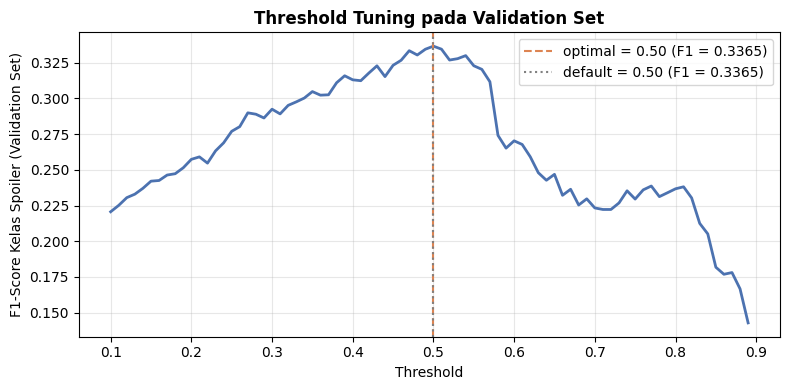

In [17]:
# cari threshold optimal di validation set
# threshold optimal = nilai yang menghasilkan F1 spoiler tertinggi di val set
thresholds     = np.arange(0.1, 0.9, 0.01)
f1_val_scores  = []

for thresh in thresholds:
  y_pred = (val_probs >= thresh).astype(int)
  f1 = f1_score(y_val_arr, y_pred, pos_label=1, zero_division=0)
  f1_val_scores.append(f1)

best_idx       = np.argmax(f1_val_scores)
best_threshold = thresholds[best_idx]
best_f1_val    = f1_val_scores[best_idx]

# F1 pada threshold default 0.5 sebagai pembanding
default_idx = np.argmin(np.abs(thresholds - 0.5))
f1_default  = f1_val_scores[default_idx]

print(f"threshold optimal (dari val set) : {best_threshold:.2f}")
print(f"F1 spoiler pada threshold optimal : {best_f1_val:.4f}")
print(f"F1 spoiler pada threshold default : {f1_default:.4f}")
print(f"\nthreshold ini akan dipakai untuk evaluasi di test set")

# visualisasi threshold vs F1 spoiler
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_val_scores, color="#4C72B0", lw=2)
plt.axvline(x=best_threshold, color="#DD8452", linestyle="--",
            label=f"optimal = {best_threshold:.2f} (F1 = {best_f1_val:.4f})")
plt.axvline(x=0.5, color="gray", linestyle=":",
            label=f"default = 0.50 (F1 = {f1_default:.4f})")
plt.xlabel("Threshold")
plt.ylabel("F1-Score Kelas Spoiler (Validation Set)")
plt.title("Threshold Tuning pada Validation Set", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("bert_threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# sekarang evaluasi di TEST SET menggunakan threshold yang ditemukan di val set
print("menghitung prediksi di test set...")
test_predictions = trainer.predict(test_dataset)
test_logits = test_predictions.predictions
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1)[:, 1].numpy()
y_test_arr = np.array(y_test)

# prediksi dengan threshold default dan threshold optimal
y_pred_default = (test_probs >= 0.50).astype(int)
y_pred_optimal = (test_probs >= best_threshold).astype(int)

# AUC tidak bergantung threshold
test_auc = roc_auc_score(y_test_arr, test_probs)

print("EVALUASI DI TEST SET")
print(f"\nAUC-ROC (tidak bergantung threshold): {test_auc:.4f}")

print(f"\nthreshold default (0.50)")
print(classification_report(
  y_test_arr, y_pred_default,
  target_names=["non-spoiler (0)", "spoiler (1)"],
  digits=4
))

print(f"\nthreshold optimal ({best_threshold:.2f})")
print(classification_report(
  y_test_arr, y_pred_optimal,
  target_names=["non-spoiler (0)", "spoiler (1)"],
  digits=4
))

menghitung prediksi di test set...


EVALUASI DI TEST SET

AUC-ROC (tidak bergantung threshold): 0.7554

threshold default (0.50)
                 precision    recall  f1-score   support

non-spoiler (0)     0.9396    0.8843    0.9111      2057
    spoiler (1)     0.2516    0.4061    0.3107       197

       accuracy                         0.8425      2254
      macro avg     0.5956    0.6452    0.6109      2254
   weighted avg     0.8794    0.8425    0.8586      2254


threshold optimal (0.50)
                 precision    recall  f1-score   support

non-spoiler (0)     0.9396    0.8843    0.9111      2057
    spoiler (1)     0.2516    0.4061    0.3107       197

       accuracy                         0.8425      2254
      macro avg     0.5956    0.6452    0.6109      2254
   weighted avg     0.8794    0.8425    0.8586      2254



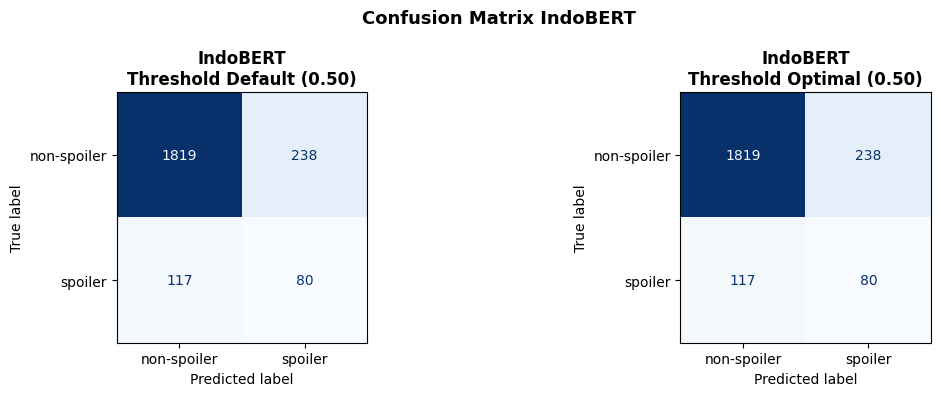

In [19]:
# confusion matrix: default vs optimal
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (title, y_pred) in zip(axes, [
  ("Threshold Default (0.50)", y_pred_default),
  (f"Threshold Optimal ({best_threshold:.2f})", y_pred_optimal)
]):
  cm = confusion_matrix(y_test_arr, y_pred)
  disp = ConfusionMatrixDisplay(
      confusion_matrix=cm,
      display_labels=["non-spoiler", "spoiler"]
  )
  disp.plot(ax=ax, colorbar=False, cmap="Blues")
  ax.set_title(f"IndoBERT\n{title}", fontweight="bold")

plt.suptitle("Confusion Matrix IndoBERT", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("bert_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

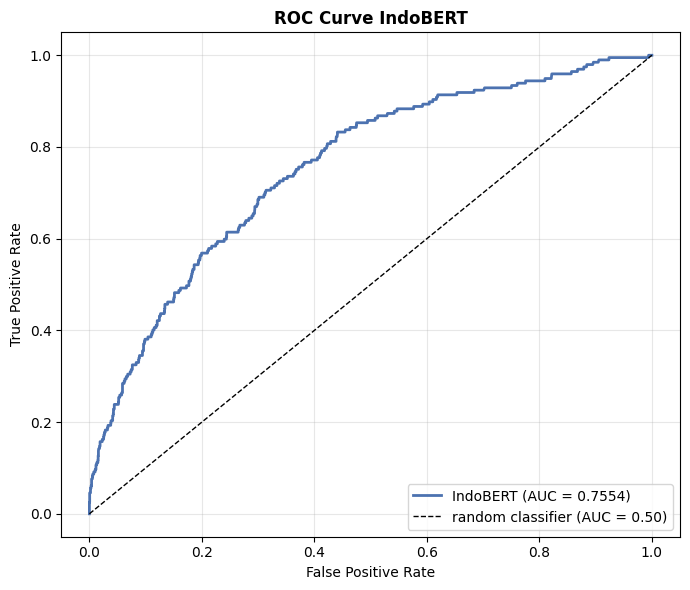

In [20]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test_arr, test_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"IndoBERT (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random classifier (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve IndoBERT", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("bert_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Analisis Training History

HuggingFace Trainer menyimpan log metrik per epoch selama training. Dengan memvisualisasikannya, kita bisa melihat apakah model mengalami overfitting, kapan performa terbaik dicapai, dan seberapa stabil proses training.

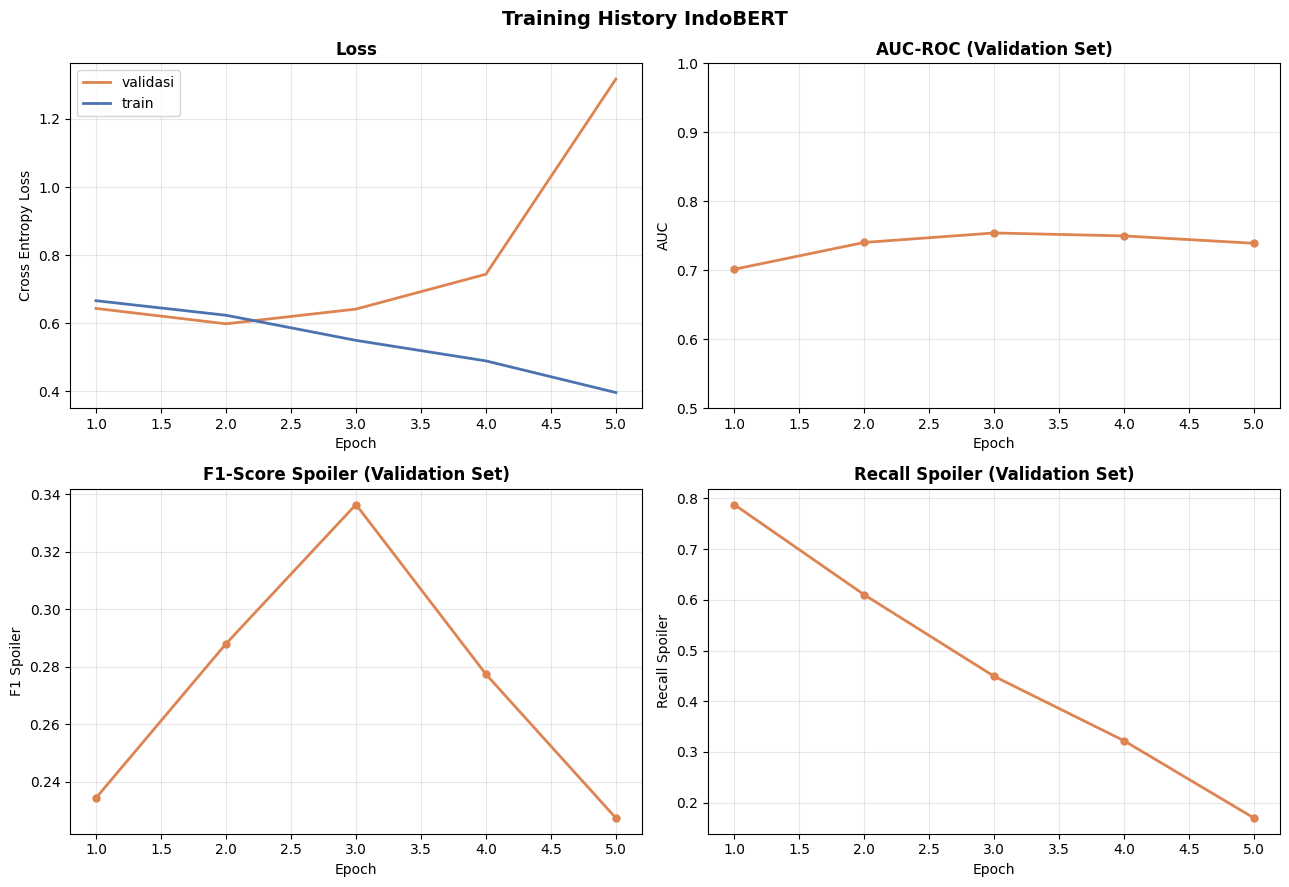

epoch terbaik (AUC tertinggi): epoch 3 (AUC = 0.7541)
training berhenti di epoch: 5


In [21]:
# ekstrak log training dari trainer
log_history = trainer.state.log_history

# pisahkan log training dan evaluasi
# log training berisi 'loss', log evaluasi berisi 'eval_loss'
train_logs = [l for l in log_history if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in log_history if "eval_loss" in l]

if not eval_logs:
  print("log evaluasi tidak tersedia, skip plotting")
else:
  epochs = [l["epoch"] for l in eval_logs]
  eval_loss = [l["eval_loss"] for l in eval_logs]
  eval_auc = [l.get("eval_auc_roc", 0) for l in eval_logs]
  eval_f1 = [l.get("eval_f1_spoiler", 0) for l in eval_logs]
  eval_rec = [l.get("eval_recall_spoiler", 0) for l in eval_logs]

  # ambil train loss per epoch kalau tersedia
  train_loss_per_epoch = [l["loss"] for l in train_logs if "loss" in l][:len(epochs)]

  fig, axes = plt.subplots(2, 2, figsize=(13, 9))

  # loss
  axes[0,0].plot(epochs, eval_loss, color="#DD8452", lw=2, label="validasi")
  if train_loss_per_epoch:
    axes[0,0].plot(epochs[:len(train_loss_per_epoch)],
                    train_loss_per_epoch, color="#4C72B0", lw=2, label="train")
  axes[0,0].set_title("Loss", fontweight="bold")
  axes[0,0].set_xlabel("Epoch")
  axes[0,0].set_ylabel("Cross Entropy Loss")
  axes[0,0].legend()
  axes[0,0].grid(alpha=0.3)

  # AUC-ROC
  axes[0,1].plot(epochs, eval_auc, color="#DD8452", lw=2, marker="o", markersize=5)
  axes[0,1].set_title("AUC-ROC (Validation Set)", fontweight="bold")
  axes[0,1].set_xlabel("Epoch")
  axes[0,1].set_ylabel("AUC")
  axes[0,1].set_ylim(0.5, 1.0)
  axes[0,1].grid(alpha=0.3)

  # F1 spoiler
  axes[1,0].plot(epochs, eval_f1, color="#DD8452", lw=2, marker="o", markersize=5)
  axes[1,0].set_title("F1-Score Spoiler (Validation Set)", fontweight="bold")
  axes[1,0].set_xlabel("Epoch")
  axes[1,0].set_ylabel("F1 Spoiler")
  axes[1,0].grid(alpha=0.3)

  # recall spoiler
  axes[1,1].plot(epochs, eval_rec, color="#DD8452", lw=2, marker="o", markersize=5)
  axes[1,1].set_title("Recall Spoiler (Validation Set)", fontweight="bold")
  axes[1,1].set_xlabel("Epoch")
  axes[1,1].set_ylabel("Recall Spoiler")
  axes[1,1].grid(alpha=0.3)

  plt.suptitle("Training History IndoBERT", fontsize=14, fontweight="bold")
  plt.tight_layout()
  plt.savefig("bert_training_history.png", dpi=150, bbox_inches="tight")
  plt.show()

  # cari epoch terbaik
  best_epoch = epochs[np.argmax(eval_auc)]
  best_auc_epoch = max(eval_auc)
  print(f"epoch terbaik (AUC tertinggi): epoch {best_epoch:.0f} (AUC = {best_auc_epoch:.4f})")
  print(f"training berhenti di epoch: {epochs[-1]:.0f}")

In [22]:
# ringkasan metrik final untuk memudahkan perbandingan dengan model lain
print("RINGKASAN METRIK FINAL INDOBERT")
for label, y_pred in [
  ("default (0.50)", y_pred_default),
  (f"optimal ({best_threshold:.2f})", y_pred_optimal)
]:
    print(f"\nthreshold {label}")
    print(f"AUC-ROC         : {test_auc:.4f}")
    print(f"F1 makro        : {f1_score(y_test_arr, y_pred, average='macro'):.4f}")
    print(f"F1 spoiler      : {f1_score(y_test_arr, y_pred, pos_label=1, zero_division=0):.4f}")
    print(f"Presisi spoiler : {precision_score(y_test_arr, y_pred, pos_label=1, zero_division=0):.4f}")
    print(f"Recall spoiler  : {recall_score(y_test_arr, y_pred, pos_label=1, zero_division=0):.4f}")
    print(f"F1 non-spoiler  : {f1_score(y_test_arr, y_pred, pos_label=0, zero_division=0):.4f}")

RINGKASAN METRIK FINAL INDOBERT

threshold default (0.50)
AUC-ROC         : 0.7554
F1 makro        : 0.6109
F1 spoiler      : 0.3107
Presisi spoiler : 0.2516
Recall spoiler  : 0.4061
F1 non-spoiler  : 0.9111

threshold optimal (0.50)
AUC-ROC         : 0.7554
F1 makro        : 0.6109
F1 spoiler      : 0.3107
Presisi spoiler : 0.2516
Recall spoiler  : 0.4061
F1 non-spoiler  : 0.9111


In [23]:
print("CEK BOBOT YANG DIPAKAI")
print(f"AUC terbaik (dari log): {trainer.state.best_metric:.4f}")
print(f"path model terbaik: {trainer.state.best_model_checkpoint}")
print()

print("LOG PER EPOCH")
for log in trainer.state.log_history:
  if "eval_auc_roc" in log:
    print(f"epoch {log['epoch']:.0f} | eval_loss: {log['eval_loss']:.4f} | eval_auc: {log['eval_auc_roc']:.4f} | eval_f1: {log.get('eval_f1_spoiler', 0):.4f}")

CEK BOBOT YANG DIPAKAI
AUC terbaik (dari log): 0.7541
path model terbaik: /content/drive/MyDrive/NLP_Kelompok3/indobert_output/checkpoint-1437

LOG PER EPOCH
epoch 1 | eval_loss: 0.6434 | eval_auc: 0.7014 | eval_f1: 0.2343
epoch 2 | eval_loss: 0.5982 | eval_auc: 0.7403 | eval_f1: 0.2880
epoch 3 | eval_loss: 0.6415 | eval_auc: 0.7541 | eval_f1: 0.3365
epoch 4 | eval_loss: 0.7439 | eval_auc: 0.7498 | eval_f1: 0.2774
epoch 5 | eval_loss: 1.3173 | eval_auc: 0.7391 | eval_f1: 0.2273


## 10. Kesimpulan dan Catatan Metodologis

### Apa yang berbeda dari BiLSTM?

IndoBERT membawa dua keunggulan fundamental dibanding BiLSTM dengan FastText:

Pertama, **konteks bidirectional yang sesungguhnya**. BiLSTM membaca kiri ke kanan dan kanan ke kiri secara terpisah lalu menggabungkan hasilnya. BERT memproses seluruh kalimat **sekaligus** melalui mekanisme self-attention, sehingga setiap kata langsung melihat semua kata lain dalam satu langkah. Ini bukan hanya perbedaan teknis, representasi yang dihasilkan jauh lebih kaya konteks.

Kedua, **pengetahuan bahasa yang jauh lebih dalam**. FastText memberikan satu vektor per kata yang dipelajari dari kemunculan kata tersebut secara statistik. BERT menghasilkan representasi yang **kontekstual**: kata "mati" dalam kalimat "baterai mati" dan "tokoh utama mati" mendapat representasi vektor yang berbeda karena BERT mempertimbangkan konteks seluruh kalimat.

### Keterbatasan

IndoBERT memiliki batas maksimum 512 token per input. Dengan MAX_LEN=256 yang dipakai di sini, sebagian review panjang terpotong. Informasi di bagian akhir review yang terpotong tidak dipertimbangkan model, dan ini bisa merugikan jika spoiler justru disebutkan di bagian akhir ulasan.

Selain itu, fine-tuning BERT membutuhkan GPU yang memadai dan waktu yang lebih lama dibanding model ML klasik. Untuk skenario produksi atau eksperimen berulang, ini bisa menjadi hambatan praktis yang signifikan.